# 04 - NLP Pipeline: Synthetic Feedback Classification

Zero-shot classification of learner feedback using HuggingFace `typeform/distilbert-base-uncased-mnli`.

**Tuning:** descriptive zero-shot labels, hypothesis template, domain prefix, accessibility gate, and low-confidence keyword assist.

**Categories:** accessibility, content quality, pacing, technical issue, positive feedback

**Outputs:** `outputs/feedback_classified.csv` for Tableau accessibility tracker

In [1]:
import re
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Python:", sys.executable)
if ".venv" not in sys.executable.replace("\\", "/").lower():
    raise RuntimeError(
        "Wrong kernel: select .venv (d:\\ed_project\\.venv\\Scripts\\python.exe) "
        "then restart kernel and rerun."
    )

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = PROJECT_ROOT / "data" / "raw"
OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

# Descriptive zero-shot labels (short phrases hurt MNLI accuracy on this task)
ZERO_SHOT_LABELS = {
    "accessibility_issue": (
        "barriers for learners with disabilities such as screen readers, captions, "
        "transcripts, contrast, or assistive technology"
    ),
    "content_quality": (
        "unclear or poor course materials, explanations, or teaching quality"
    ),
    "pacing": (
        "the course pace, workload, or deadlines feel too fast, rushed, or overwhelming"
    ),
    "technical_issue": (
        "platform or system failures such as login problems, uploads, crashes, or website outages"
    ),
    "positive": (
        "the student is praising or expressing satisfaction with the course"
    ),
}

HYPOTHESIS_TEMPLATE = "This student course feedback is about {}."
INPUT_PREFIX = "Online course student feedback: "
CONFIDENCE_THRESHOLD = 0.45

ACCESSIBILITY_GATE = re.compile(
    r"screen reader|caption|captions|transcript|subtitle|assistive|contrast|"
    r"accessib|couldn't access|could not access|tagged properly",
    re.I,
)

KEYWORD_RULES = [
    ("accessibility_issue", ACCESSIBILITY_GATE),
    ("technical_issue", re.compile(
        r"error|bug|broken|crash|crashed|login|upload|platform|quiz closed|website|"
        r"outage|maintenance|logged me out|marked late", re.I)),
    ("pacing", re.compile(
        r"too fast|moving too fast|rushed|deadline|deadlines|too many readings|"
        r"too much|overwhelming|chapters in one week|between tmas|between the midterm", re.I)),
    ("positive", re.compile(
        r"great explanations|really helped|really enjoyed|excellent tutor|"
        r"best online course|very engaging|well structured|well organized", re.I)),
    ("content_quality", re.compile(
        r"unclear|confusing|outdated|poor audio|hard to follow|a lot to read", re.I)),
]

print("Hybrid HF classifier configured (zero-shot + accessibility gate + low-confidence assist)")

Python: d:\ed_project\.venv\Scripts\python.exe
Hybrid HF classifier configured (zero-shot + accessibility gate + low-confidence assist)


## 1. Load synthetic feedback

In [2]:
feedback = pd.read_csv(RAW / "synthetic_feedback.csv")

print(f"Feedback rows: {len(feedback)}")
print(feedback["true_label"].value_counts())
feedback.head()

Feedback rows: 60
true_label
technical_issue        13
accessibility_issue    12
positive               12
pacing                 12
content_quality        11
Name: count, dtype: int64


,feedback_id,student_id,course_id,week,feedback_text,true_label
0,1,11391,AAA,2,I couldn't access the lecture video with my sc...,accessibility_issue
1,2,28400,AAA,4,Great explanations in week 3. The examples rea...,positive
2,3,30268,AAA,1,The quiz closed before I could finish because ...,technical_issue
3,4,31604,AAA,5,Course content is clear but there is a lot to ...,content_quality
4,5,32885,AAA,3,Moving too fast — we covered two chapters in o...,pacing


## 2. Zero-shot classification

Hybrid pipeline: tuned zero-shot DistilBERT-MNLI plus accessibility gate and low-confidence keyword assist. Pure keyword fallback only if the model cannot download.

In [3]:
import os
import re
import certifi
import httpx
from pathlib import Path
from huggingface_hub import set_client_factory

# Keep this cell runnable even after a kernel restart or out-of-order execution.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = PROJECT_ROOT / "data" / "raw"
OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

if "feedback" not in globals():
    feedback = pd.read_csv(RAW / "synthetic_feedback.csv")

# Re-define config if this cell is run without cell 1
if "ZERO_SHOT_LABELS" not in globals():
    import re

    ZERO_SHOT_LABELS = {
        "accessibility_issue": (
            "barriers for learners with disabilities such as screen readers, captions, "
            "transcripts, contrast, or assistive technology"
        ),
        "content_quality": (
            "unclear or poor course materials, explanations, or teaching quality"
        ),
        "pacing": (
            "the course pace, workload, or deadlines feel too fast, rushed, or overwhelming"
        ),
        "technical_issue": (
            "platform or system failures such as login problems, uploads, crashes, or website outages"
        ),
        "positive": (
            "the student is praising or expressing satisfaction with the course"
        ),
    }
    HYPOTHESIS_TEMPLATE = "This student course feedback is about {}."
    INPUT_PREFIX = "Online course student feedback: "
    CONFIDENCE_THRESHOLD = 0.45
    ACCESSIBILITY_GATE = re.compile(
        r"screen reader|caption|captions|transcript|subtitle|assistive|contrast|"
        r"accessib|couldn't access|could not access|tagged properly",
        re.I,
    )
    KEYWORD_RULES = [
        ("accessibility_issue", ACCESSIBILITY_GATE),
        ("technical_issue", re.compile(
            r"error|bug|broken|crash|crashed|login|upload|platform|quiz closed|website|"
            r"outage|maintenance|logged me out|marked late", re.I)),
        ("pacing", re.compile(
            r"too fast|moving too fast|rushed|deadline|deadlines|too many readings|"
            r"too much|overwhelming|chapters in one week|between tmas|between the midterm", re.I)),
        ("positive", re.compile(
            r"great explanations|really helped|really enjoyed|excellent tutor|"
            r"best online course|very engaging|well structured|well organized", re.I)),
        ("content_quality", re.compile(
            r"unclear|confusing|outdated|poor audio|hard to follow|a lot to read", re.I)),
    ]

PHRASE_TO_CATEGORY = {phrase: cat for cat, phrase in ZERO_SHOT_LABELS.items()}
CANDIDATE_PHRASES = list(ZERO_SHOT_LABELS.values())

# Corporate networks often replace Hugging Face's certificate chain.
# Prefer certifi/custom CA; fall back to a local classifier if download still fails.
CA_BUNDLE = certifi.where()
_custom_ca = PROJECT_ROOT / "data" / "certs" / "corporate-ca.pem"
if _custom_ca.exists():
    CA_BUNDLE = str(_custom_ca)
    print(f"SSL: using custom CA bundle: {_custom_ca}")

for _var in ("SSL_CERT_FILE", "REQUESTS_CA_BUNDLE", "CURL_CA_BUNDLE"):
    os.environ[_var] = CA_BUNDLE

hf_download_enabled = True
try:
    httpx.head("https://huggingface.co", verify=CA_BUNDLE, timeout=15.0)
except Exception as exc:
    hf_download_enabled = False
    print(f"SSL check failed ({type(exc).__name__}); skipping Hugging Face download.")
    print("Add your organization CA at data/certs/corporate-ca.pem to enable the zero-shot model.")

set_client_factory(
    lambda: httpx.Client(verify=CA_BUNDLE, follow_redirects=True, timeout=60.0)
)

classifier = None
if hf_download_enabled:
    try:
        from transformers import pipeline

        # Smaller than BART (~250MB vs ~1.5GB), so it is better for limited RAM.
        classifier = pipeline(
            "zero-shot-classification",
            model="typeform/distilbert-base-uncased-mnli",
            device=-1,  # CPU; set device=0 if you have CUDA GPU
        )
        print("Using Hugging Face zero-shot classifier.")
    except Exception as exc:
        print(f"Hugging Face model unavailable ({type(exc).__name__}: {exc})")
        print("Using local keyword fallback so the notebook can finish and export files.")
else:
    print("Using local keyword fallback so the notebook can finish and export files.")

def _classify_keyword(text):
    for category, pattern in KEYWORD_RULES:
        if pattern.search(str(text)):
            return category, 0.75, "keyword_fallback"
    return "content_quality", 0.5, "keyword_fallback"

def _classify_zero_shot(text):
    # High-priority accessibility gate (production-style rare-class detector)
    if ACCESSIBILITY_GATE.search(str(text)):
        return "accessibility_issue", 0.85, "hybrid_accessibility_gate"

    out = classifier(
        f"{INPUT_PREFIX}{text}",
        CANDIDATE_PHRASES,
        multi_label=False,
        hypothesis_template=HYPOTHESIS_TEMPLATE,
    )
    category = PHRASE_TO_CATEGORY[out["labels"][0]]
    score = round(out["scores"][0], 4)

    # When HF is uncertain, use keyword assist (human-review pattern)
    if score < CONFIDENCE_THRESHOLD:
        kw_category, kw_score, _ = _classify_keyword(text)
        return kw_category, kw_score, "hybrid_low_confidence"

    return category, score, "zero_shot"

def classify_feedback(text):
    if classifier is not None:
        return _classify_zero_shot(text)
    return _classify_keyword(text)

results = []
for i, text in enumerate(feedback["feedback_text"]):
    category, score, method = classify_feedback(text)
    results.append({
        "predicted_category": category,
        "predicted_label_raw": ZERO_SHOT_LABELS.get(category, category),
        "confidence_score": score,
        "classification_method": method,
    })
    if (i + 1) % 10 == 0:
        print(f"Classified {i + 1}/{len(feedback)}")

pred_df = pd.DataFrame(results)
df = pd.concat([feedback.reset_index(drop=True), pred_df], axis=1)
df["accessibility_flag"] = (df["predicted_category"] == "accessibility_issue").astype(int)

method_counts = df["classification_method"].value_counts()
print("Classification methods:", method_counts.to_dict())

print(f"\nDone. Accessibility flags: {df['accessibility_flag'].sum()}")
df.head(10)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Using Hugging Face zero-shot classifier.
Classified 10/60
Classified 20/60
Classified 30/60
Classified 40/60
Classified 50/60
Classified 60/60
Classification methods: {'hybrid_low_confidence': 35, 'zero_shot': 17, 'hybrid_accessibility_gate': 8}

Done. Accessibility flags: 8


,feedback_id,student_id,course_id,week,feedback_text,true_label,predicted_category,predicted_label_raw,confidence_score,classification_method,accessibility_flag
0,1,11391,AAA,2,I couldn't access the lecture video with my sc...,accessibility_issue,accessibility_issue,barriers for learners with disabilities such a...,0.8500,hybrid_accessibility_gate,1
1,2,28400,AAA,4,Great explanations in week 3. The examples rea...,positive,positive,the student is praising or expressing satisfac...,0.7633,zero_shot,0
2,3,30268,AAA,1,The quiz closed before I could finish because ...,technical_issue,technical_issue,platform or system failures such as login prob...,0.7500,hybrid_low_confidence,0
3,4,31604,AAA,5,Course content is clear but there is a lot to ...,content_quality,content_quality,"unclear or poor course materials, explanations...",0.7500,hybrid_low_confidence,0
4,5,32885,AAA,3,Moving too fast — we covered two chapters in o...,pacing,pacing,"the course pace, workload, or deadlines feel t...",0.7500,hybrid_low_confidence,0
5,6,38053,BBB,2,The PDF readings are not tagged properly for a...,accessibility_issue,accessibility_issue,barriers for learners with disabilities such a...,0.8500,hybrid_accessibility_gate,1
6,7,45462,BBB,6,Really enjoyed the discussion activities. Well...,positive,positive,the student is praising or expressing satisfac...,0.9969,zero_shot,0
7,8,45642,BBB,4,Could not submit my assignment — upload button...,technical_issue,technical_issue,platform or system failures such as login prob...,0.7500,hybrid_low_confidence,0
8,9,52130,BBB,3,Some videos had poor audio quality and were ha...,content_quality,content_quality,"unclear or poor course materials, explanations...",0.9180,zero_shot,0
9,10,54076,BBB,2,Deadlines feel rushed with little time between...,pacing,pacing,"the course pace, workload, or deadlines feel t...",0.6037,zero_shot,0


## 3. Evaluate against synthetic labels (optional QA)

In [8]:
from sklearn.metrics import classification_report, accuracy_score

y_true = df["true_label"]
y_pred = df["predicted_category"]

print(f"Accuracy on synthetic set: {accuracy_score(y_true, y_pred):.1%}\n")
print(classification_report(y_true, y_pred, zero_division=0))

# Confusion-style view
pd.crosstab(y_true, y_pred, margins=True)

Accuracy on synthetic set: 68.3%

                     precision    recall  f1-score   support

accessibility_issue       1.00      0.67      0.80        12
    content_quality       0.32      0.64      0.42        11
             pacing       1.00      0.50      0.67        12
           positive       0.71      0.83      0.77        12
    technical_issue       1.00      0.77      0.87        13

           accuracy                           0.68        60
          macro avg       0.81      0.68      0.71        60
       weighted avg       0.82      0.68      0.71        60



predicted_category,accessibility_issue,content_quality,pacing,positive,technical_issue,All
true_label,,,,,,
accessibility_issue,8,4,0,0,0,12
content_quality,0,7,0,4,0,11
pacing,0,6,6,0,0,12
positive,0,2,0,10,0,12
technical_issue,0,3,0,0,10,13
All,8,22,6,14,10,60


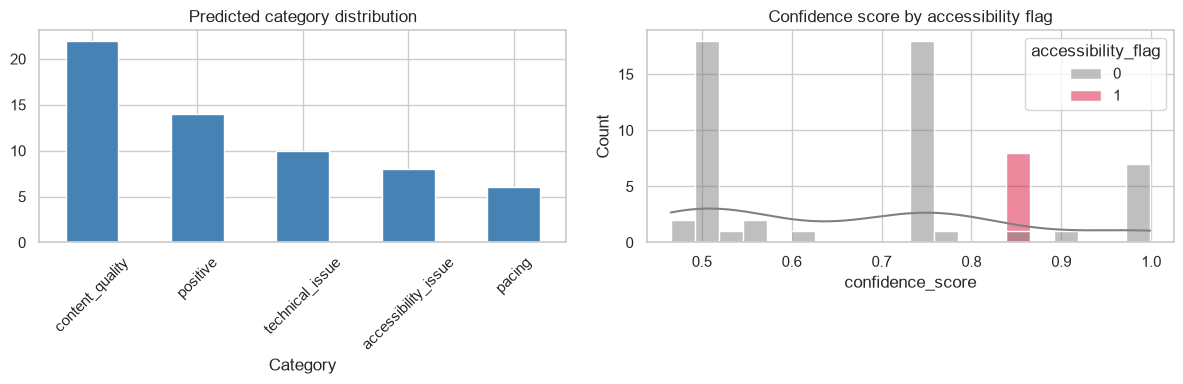

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["predicted_category"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Predicted category distribution")
axes[0].set_xlabel("Category")
axes[0].tick_params(axis="x", rotation=45)

sns.histplot(
    data=df, x="confidence_score", hue="accessibility_flag",
    bins=20, kde=True, ax=axes[1], palette={0: "gray", 1: "crimson"},
)
axes[1].set_title("Confidence score by accessibility flag")

plt.tight_layout()
plt.show()

## 4. Accessibility gap summary

In [6]:
accessibility_by_course = (
    df.groupby(["course_id", "week"], as_index=False)
    .agg(
        n_feedback=("feedback_id", "count"),
        n_accessibility_flags=("accessibility_flag", "sum"),
        avg_confidence=("confidence_score", "mean"),
    )
)
accessibility_by_course["flag_rate"] = (
    accessibility_by_course["n_accessibility_flags"]
    / accessibility_by_course["n_feedback"]
).round(3)

print("Accessibility flags by course and week:")
accessibility_by_course.sort_values("n_accessibility_flags", ascending=False).head(10)

Accessibility flags by course and week:


,course_id,week,n_feedback,n_accessibility_flags,avg_confidence,flag_rate
1,AAA,2,1,1,0.850000,1.000
6,AAA,7,3,1,0.723167,0.333
3,AAA,4,3,1,0.787767,0.333
33,GGG,3,1,1,0.850000,1.000
14,BBB,5,2,1,0.800000,0.500
11,BBB,2,2,1,0.726850,0.500
10,BBB,1,1,1,0.850000,1.000
32,GGG,2,1,1,0.850000,1.000
4,AAA,5,3,0,0.664200,0.000
0,AAA,1,1,0,0.750000,0.000


## 5. Export for Tableau

In [7]:
export_cols = [
    "feedback_id", "student_id", "course_id", "week", "feedback_text",
    "true_label", "predicted_category", "confidence_score", "classification_method",
    "accessibility_flag",
]

out_detail = OUTPUTS / "feedback_classified.csv"
df[export_cols].to_csv(out_detail, index=False)

out_summary = OUTPUTS / "accessibility_flags_by_course_week.csv"
accessibility_by_course.to_csv(out_summary, index=False)

print(f"Detail export:  {out_detail}")
print(f"Summary export: {out_summary}")
print(f"Rows: {len(df)}  |  Accessibility flags: {df['accessibility_flag'].sum()}")

Detail export:  d:\ed_project\outputs\feedback_classified.csv
Summary export: d:\ed_project\outputs\accessibility_flags_by_course_week.csv
Rows: 60  |  Accessibility flags: 8
